> **Note:** this notebook is a copy of `agarwal.ipynb` from the [CDEI-Bias-Mitigation](https://github.com/Durham-Decolonisation-Maths/CDEI-Bias-Mitigation) repository, included here purely for classroom convenience so it sits next to `fairvgnn.ipynb`. It is tabular (Adult census data), not graph data — it has nothing to do with Pokec-z or GNNs. Teach it first, then `fairvgnn.ipynb` in this repo shows the same min-max idea with a neural discriminator in place of the Lagrange multiplier. The canonical copy lives in CDEI-Bias-Mitigation; if you edit one, keep the other in sync by hand.

# Fair Classification as Constrained Optimisation — Agarwal et al. - Adult data

This notebook contains an implementation of the **in-processing** intervention introduced in [A Reductions Approach to Fair Classification](http://proceedings.mlr.press/v80/agarwal18a.html) by Agarwal, Beygelzimer, Dudík, Langford and Wallach (2018), as implemented in the [Fairlearn toolbox](https://github.com/fairlearn/fairlearn).

Where FTU and reweighing act on the *data* and Hardt et al.'s method acts on a trained model's *decisions*, this method changes the *training objective itself*: it casts fair classification as a constrained optimisation problem and solves it directly. This is the formulation worth seeing before FairVGNN, which uses the same Lagrangian idea but with a neural discriminator standing in for the multipliers.

## The optimisation problem

Ordinary empirical risk minimisation picks the classifier $h$ that minimises average loss:

$$\min_{h \in \mathcal{H}} \; \mathrm{err}(h) = \frac{1}{n}\sum_{i=1}^n \mathrm{loss}\big(h(x_i), y_i\big)$$

A group fairness notion — demographic parity, equalised odds, equal opportunity — can be written as a set of **linear constraints** on the classifier's conditional selection rates. For demographic parity with protected attribute $A$, we want the selection rate within every group to sit within $\varepsilon$ of the overall selection rate:

$$\big|\, \mathbb{P}(h(X){=}1 \mid A{=}a) - \mathbb{P}(h(X){=}1) \,\big| \le \varepsilon \quad \text{for every group } a$$

Stacking these (as two-sided inequalities, one pair per group) gives a general linear constraint $M\,\mu(h) \le c$, and the fair classification problem becomes:

$$\min_{h \in \mathcal{H}} \; \mathrm{err}(h) \quad \text{subject to} \quad M\,\mu(h) \le c$$

## The Lagrangian and the two-player game

Introduce a Lagrange multiplier $\lambda \ge 0$ for every constraint row and form the Lagrangian:

$$L(h, \lambda) = \mathrm{err}(h) + \lambda^{\top}\big(M\,\mu(h) - c\big)$$

The constrained problem is the saddle point $\min_h \max_{\lambda \ge 0} L(h,\lambda)$. Agarwal et al.'s key observation is that this saddle point can be found by treating it as a **zero-sum game** between two players:

- **The learner** picks $h$ to minimise $L(h,\lambda)$ for the current $\lambda$. For a fixed $\lambda$, this is just a *cost-sensitive classification problem* — the $\lambda$ terms act as per-example weights — so any ordinary classifier that accepts sample weights can play this role.
- **The regulator** picks $\lambda$ to maximise $L(h,\lambda)$ for the current $h$, i.e. it increases the penalty on whichever constraints are currently most violated. This is a textbook online-learning problem, solved here by the **exponentiated gradient** algorithm (multiplicative weights) — the source of the method's name, `ExponentiatedGradient`.

The two players alternate best-responses; the average classifier over the game's history converges to the constrained optimum. Unlike Hardt et al.'s method, this gives a *continuous* trade-off — the tolerance $\varepsilon$ directly controls how much fairness is traded for accuracy — and unlike FTU or reweighing, the mechanism generalises to essentially any linear fairness constraint by swapping out $M$ and $c$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
)
from fairlearn.reductions import DemographicParity, EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression
import joblib

from helpers.metrics import accuracy
from helpers.plot import group_bar_plots

The baseline model was pickled with an older scikit-learn version, and this notebook pulls in libraries with newer, stricter validation than the versions the original CDEI project pinned in 2020. The cell below silences the resulting (harmless) version-compatibility warnings so the output stays focused on the fairness results.

In [2]:
import warnings

warnings.filterwarnings("ignore")

## Load data

Same preprocessed Adult census data as the other three intervention notebooks.

In [3]:
artifacts_dir = Path("artifacts")

In [4]:
data_dir = artifacts_dir / "data" / "adult"

train = pd.read_csv(data_dir / "processed" / "train-one-hot.csv")
test = pd.read_csv(data_dir / "processed" / "test-one-hot.csv")

sex_train = train.sex.map({0: "female", 1: "male"})

## Load baseline model

For comparison, the same unmodified baseline used throughout this repository.

In [5]:
baseline_model = joblib.load(artifacts_dir / "models" / "finance" / "baseline.pkl")

bl_test_probs = baseline_model.predict_proba(test.drop("salary", axis=1))[:, 1]
bl_test_pred = (bl_test_probs > 0.5).astype(int)

## Play the game: demographic parity

`ExponentiatedGradient` needs a base classifier that accepts `sample_weight` — we use logistic regression (the baseline model is an `MLPClassifier`, which `fairlearn`'s reductions cannot re-weight directly). `max_iter` bounds how many rounds of the learner/regulator game are played; each round retrains the base classifier once, so this is genuinely running the optimisation live rather than loading a precomputed result.

In [6]:
constraint = DemographicParity()
classifier = LogisticRegression(max_iter=2000)

mitigator = ExponentiatedGradient(classifier, constraint, max_iter=30)
mitigator.fit(train.drop("salary", axis=1), train.salary.values, sensitive_features=sex_train)

print(f"Converged after {mitigator.last_iter_ + 1} rounds, "
      f"best constraint violation found: {mitigator.best_gap_:.4f}")

Converged after 6 rounds, best constraint violation found: 0.0003


### Watching the Lagrangian game converge

`lambda_vecs_` records the multiplier the regulator assigned to every constraint at every round. Demographic parity is expressed as two-sided constraints (`+`/`-`) for each group, so there are four multiplier trajectories here. Early on, the regulator pushes hard on whichever group's constraint the learner is violating; as the learner's classifier improves, the multipliers settle down.

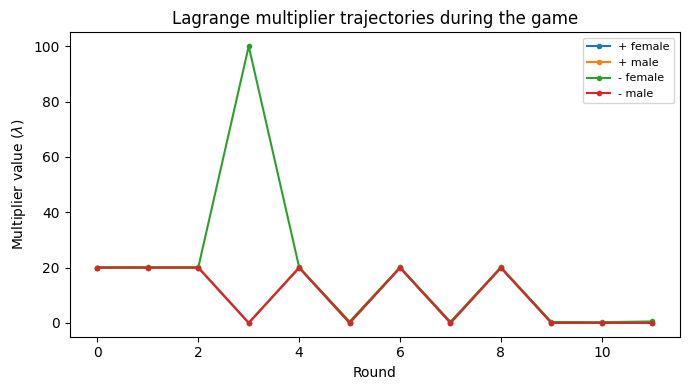

In [7]:
lambdas = mitigator.lambda_vecs_

fig, ax = plt.subplots(figsize=(7, 4))
for idx in lambdas.index:
    ax.plot(lambdas.columns, lambdas.loc[idx], marker="o", markersize=3,
            label=f"{idx[0]} {idx[2]}")
ax.set_xlabel("Round")
ax.set_ylabel(r"Multiplier value ($\lambda$)")
ax.set_title("Lagrange multiplier trajectories during the game")
ax.legend(fontsize=8)
fig.tight_layout()
fig.show()

### Analyse fairness and accuracy on test data

In [8]:
test_pred = mitigator.predict(test.drop("salary", axis=1))

bl_acc = accuracy(test.salary, bl_test_probs)
bl_dpd = demographic_parity_difference(test.salary, bl_test_pred, sensitive_features=test.sex)

acc = accuracy(test.salary, test_pred)
dpd = demographic_parity_difference(test.salary, test_pred, sensitive_features=test.sex)

print(f"Baseline accuracy: {bl_acc:.3f}")
print(f"Reductions accuracy: {acc:.3f}\n")

print(f"Baseline demographic parity difference: {bl_dpd:.3f}")
print(f"Reductions demographic parity difference: {dpd:.3f}")

Baseline accuracy: 0.853
Reductions accuracy: 0.829

Baseline demographic parity difference: 0.193
Reductions demographic parity difference: 0.014


In [9]:
dp_bar = group_bar_plots(
    test_pred,
    test.sex.map({0: "Female", 1: "Male"}),
    title="Predictions by sex (reductions, demographic parity)",
    xlabel="Proportion predicted high earners",
)
dp_bar

## Swap the constraint: equalised odds

Because the fairness notion enters only through $M$ and $c$, switching from demographic parity to equalised odds needs no change to the algorithm — only to the constraint object we hand it. This is the payoff of the constrained-optimisation view: fairness notions become interchangeable *constraints* on the same underlying problem, rather than separate bespoke algorithms.

In [10]:
constraint = EqualizedOdds()
classifier = LogisticRegression(max_iter=2000)

mitigator_eo = ExponentiatedGradient(classifier, constraint, max_iter=30)
mitigator_eo.fit(train.drop("salary", axis=1), train.salary.values, sensitive_features=sex_train)

test_pred_eo = mitigator_eo.predict(test.drop("salary", axis=1))

bl_eod = equalized_odds_difference(test.salary, bl_test_pred, sensitive_features=test.sex)
eod = equalized_odds_difference(test.salary, test_pred_eo, sensitive_features=test.sex)
acc_eo = accuracy(test.salary, test_pred_eo)

print(f"Baseline accuracy: {bl_acc:.3f}")
print(f"Reductions accuracy: {acc_eo:.3f}\n")

print(f"Baseline equalised odds difference: {bl_eod:.3f}")
print(f"Reductions equalised odds difference: {eod:.3f}")

Baseline accuracy: 0.853
Reductions accuracy: 0.837

Baseline equalised odds difference: 0.128
Reductions equalised odds difference: 0.024


## Discussion

This notebook completes the trio of tabular intervention *families* in this repository:

| Stage | Notebook | Where it intervenes |
| --- | --- | --- |
| Pre-processing | `ftu.ipynb`, `kamiran_calders.ipynb` | The training data |
| **In-processing** | `agarwal.ipynb` (this notebook) | The training objective |
| Post-processing | `hardt.ipynb` | The trained model's decisions |

**Discussion questions for students:**

1. `ExponentiatedGradient` took a `max_iter` argument bounding the number of rounds of the game. What do you expect happens to accuracy and to the fairness gap as `max_iter` grows? Try `max_iter=5` and `max_iter=100` and compare.
2. The Lagrangian view makes the accuracy/fairness trade-off *continuous*, controlled by $\varepsilon$ via the constraint's tolerance — unlike Hardt et al.'s method, which returns a single fixed point. Why might a policy team prefer one over the other?
3. **Forward look to FairVGNN:** the min–max game you just watched — a predictor against an adversary that penalises unfairness — is the same idea FairVGNN uses on graphs, except the "regulator" becomes a trained neural discriminator that tries to predict the sensitive attribute from node embeddings, and the "learner" is a graph encoder trying to fool it while still classifying well. Everything here (the alternating updates, the min-max structure) carries over; what changes is that the constraint is no longer a closed-form linear one, so the multiplier is replaced by a learned network.